In [4]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sys.path.append('../ProcessEvents/')
from config import CATCHMENT_LOOKUP_DICT, OUT_DIR, CATCHMENTS 

In [2]:
all_catchments = set(CATCHMENT_LOOKUP_DICT.keys())

catchments_with_flood_output = []
for catchment_num in all_catchments:
    catchment_name = CATCHMENT_LOOKUP_DICT[catchment_num]
    fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/Catchment_{catchment_num}/{catchment_name}.pkl"
    flood_fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/PluvialResults/5km_total/Catchment_{catchment_num}/Ens01_{catchment_num}/10cm/flooded_area_5km_total_Ens01_{catchment_num}_10cm.nc"
        
    if os.path.isfile(flood_fp) and os.path.isfile(fp):
        catchments_with_flood_output.append(catchment_num)
print(len(catchments_with_flood_output))

rainfall_events_all = []
for catchment_num in catchments_with_flood_output:
    catchment_name = CATCHMENT_LOOKUP_DICT[catchment_num]
    fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/Catchment_{catchment_num}/{catchment_name}.pkl"
    rainfall_events = pd.read_pickle(fp)
    rainfall_events_complete = rainfall_events[rainfall_events['mismatch']!=True].copy()
    rainfall_events['catchment_num'] = catchment_num
    rainfall_events_all.append(rainfall_events) 
rainfall_events_all_df = pd.concat(rainfall_events_all, ignore_index=True)    
rainfall_events_all_df.reset_index(inplace=True, drop = True)

113


252 zero-flood events across 49 unique cells


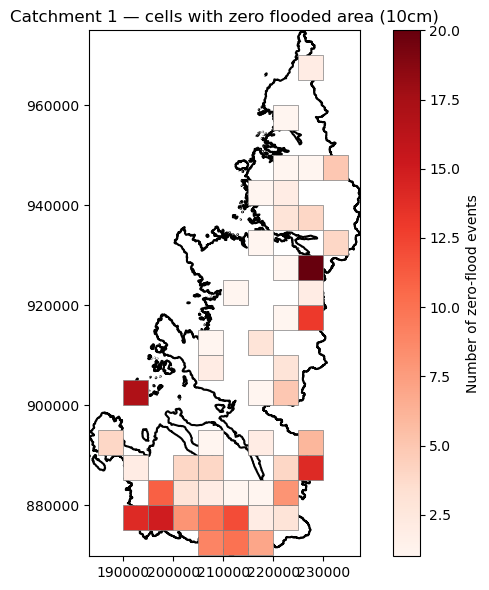

In [5]:
zero_events = rainfall_events_all_df[rainfall_events_all_df['10cm_area']==0]
catchment_num = '95'

# --- Filter and aggregate ---
cat_zero = zero_events[zero_events['catchment_num'] == catchment_num]

# Count events per unique cell (using global coords so cells match across the grid)
cell_counts = (cat_zero.groupby(['x_coord', 'y_coord']).size().reset_index(name='n_events'))

print(f"{len(cat_zero)} zero-flood events across {len(cell_counts)} unique cells")

# --- Catchment boundary ---
boundary_gdf = CATCHMENTS[CATCHMENTS['HA_NUM'] == catchment_num]

cellsize = 5000  # confirm matches your rainfall/flood grid resolution

fig, ax = plt.subplots(figsize=(7, 6))
boundary_gdf.boundary.plot(ax=ax, color='black', linewidth=1.5, zorder=1)

norm = mcolors.Normalize(vmin=cell_counts['n_events'].min(), vmax=cell_counts['n_events'].max())
cmap = plt.cm.Reds

for _, r in cell_counts.iterrows():
    ax.add_patch(plt.Rectangle((r['x_coord'] - cellsize/2, r['y_coord'] - cellsize/2),
        cellsize, cellsize,facecolor=cmap(norm(r['n_events'])),edgecolor='grey', linewidth=0.5, zorder=2))

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Number of zero-flood events')
ax.set_title("Catchment 1 — cells with zero flooded area (10cm)")
ax.set_xlim(boundary_gdf.total_bounds[[0,2]])
ax.set_ylim(boundary_gdf.total_bounds[[1,3]])
ax.set_aspect('equal')
plt.tight_layout()
plt.show()